In [1]:
# Imports
import jax
from jax import numpy as jnp
from jax import random

from flax import nnx
import optax

from matplotlib import pyplot as plt
from plotting import plot_regression_with_uncertainty

from helper import DataLoader
from functools import partial

from laplax.curv import create_ggn_mv, create_posterior_fn, estimate_curvature
from laplax.eval.pushforward import (
    lin_pred_mean,
    lin_pred_std,
    lin_pred_var,
    lin_setup,
    nonlin_pred_mean,
    nonlin_pred_std,
    nonlin_pred_var,
    nonlin_setup,
    set_lin_pushforward,
    set_nonlin_pushforward,
    set_posterior_gp_kernel,
)
seed = 239238

In [2]:
# Overview over active learning goal and procedure

In [3]:
# Data creation: Function that samples a y value given x
# and creates some small train set

def sample_labels(x, sample_variance, key):
    # Calculates labels for points x and 
    # adds unbiased Gaussian noise with sample_variance
    
    x = jnp.atleast_2d(x) # (number_points, point_dimension)
    x = x.squeeze(-1) # Assume one-dimensional x values
    y_true = jnp.sinc(x)
    noise = random.normal(key, y_true.shape) * jnp.sqrt(sample_variance)
    return y_true + noise

key = random.key(seed)
x = jnp.linspace(0.2,5,100)[:,None]

prior_variance = 0.001
y = sample_labels(x, prior_variance, key)[:,None]

dataloader = DataLoader(x, y, batch_size=10)

In [4]:
# Model definition

class Model(nnx.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, rngs):
        self.linear1 = nnx.Linear(in_channels, hidden_channels, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear3 = nnx.Linear(hidden_channels, out_channels, rngs=rngs)
    def __call__(self, x):
        x = nnx.tanh(self.linear1(x))
        x = nnx.tanh(self.linear2(x))
        return self.linear3(x)

model = Model(
    in_channels=1,
    hidden_channels=128,
    out_channels=1,
    rngs=nnx.Rngs(seed))

@nnx.jit
def train_step(model, optimizer, x, y):
    
    def loss_fn(model):
        y_pred = model(x)  # Call methods directly
        return jnp.sum((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)  # Inplace updates

    return loss, grads

In [5]:
# Model training loop

def train_model(model, data, n_epochs, lr):
    # Create optimizer
    optimizer = nnx.Optimizer(model, optax.adam(lr))  # Reference sharing

    # Train epoch
    for epoch in range(n_epochs):
        for x_batch, y_batch in dataloader:
            loss, grad = train_step(model, optimizer, x_batch, y_batch)

        if epoch % 100 == 0:
            print(f"[epoch {epoch}]: loss: {loss:.4f}")
            #print(f"                 grad: {grad}")
    print(f"Final loss: {loss:.4f}")
    return model

# Train model

model = train_model(model, dataloader, n_epochs=1000, lr=1e-3)

[epoch 0]: loss: 0.2230
[epoch 100]: loss: 0.0595
[epoch 200]: loss: 0.0646
[epoch 300]: loss: 0.0650
[epoch 400]: loss: 0.0317
[epoch 500]: loss: 0.0406
[epoch 600]: loss: 0.0367
[epoch 700]: loss: 0.0201
[epoch 800]: loss: 0.0330
[epoch 900]: loss: 0.0216
Final loss: 0.0142


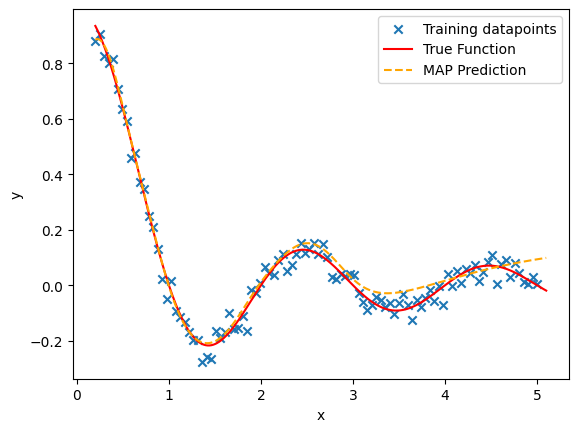

In [6]:
# Trained model visualization

plt.scatter(x, y, marker="x", label="Training datapoints")

x_pred = jnp.linspace(0.2,5.1,1000)[:,None]
y_true = sample_labels(x_pred, 0, key)
plt.plot(x_pred, y_true, color="black", linestyle="--", label="True Function")

y_pred = jax.vmap(model)(x_pred)
plt.plot(x_pred, y_pred, color="red", label="MAP Prediction")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
# Uncertainty quantification using laplax
graph_def, params = nnx.split(model)

def model_fn(input, params):
    return nnx.call((graph_def, params))(input)[0]

trainset = {"input": x, "target": y}

ggn_mv = create_ggn_mv(
    model_fn,
    params,
    trainset,
    loss_fn="mse",
)

posterior_fn = create_posterior_fn(
     curv_type="full",
     mv=ggn_mv,
     layout=params,
)

set_prob_predictive = partial(
    set_lin_pushforward,
    model_fn=model_fn,
    mean_params=params,
    posterior_fn=posterior_fn,
    pushforward_fns=[
        lin_setup,
        lin_pred_mean,
        lin_pred_var,
        lin_pred_std,
    ],
)


In [8]:
prior_arguments = {"prior_prec": 1./prior_variance} 
prob_predictive = set_prob_predictive(
    prior_arguments=prior_arguments,
)

pred = jax.vmap(prob_predictive)(x_pred)
y_mean = pred["pred_mean"][:, 0]
y_std = jnp.sqrt(pred["pred_var"][:, 0])


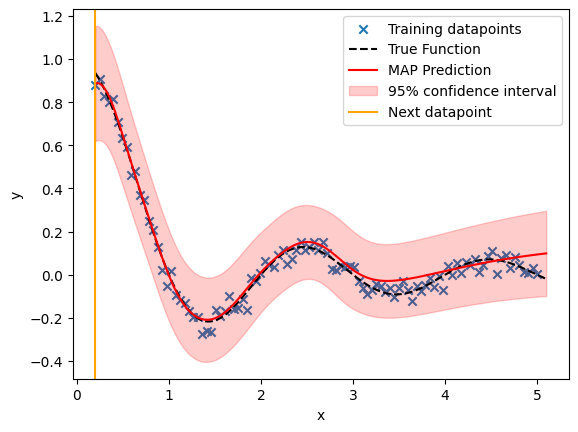

In [16]:
# Visualization with uncertainty, optimal next data point

plt.scatter(x, y, marker="x", label="Training datapoints")

plt.plot(x_pred, y_true, color="black", linestyle="--", label="True Function")

plt.plot(x_pred, y_mean, color="red", label="MAP Prediction")

plt.fill_between(
    x_pred.flatten(),
    (y_mean - 2 * y_std).flatten(),
    (y_mean + 2 * y_std).flatten(),
    color="red",
    alpha=0.2,
    label="95% confidence interval",
)

next_index = jnp.argmax(y_std)
plt.axvline(x_pred[next_index],color="orange", label="Next datapoint")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()